In [1]:
from langgraph.graph import StateGraph, START,END
from typing import TypedDict


In [8]:
class llmPrompter(TypedDict):
    topic:str
    outline:str
    blog:str

In [9]:
from dotenv import load_dotenv
from langchain_huggingface import ChatHuggingFace,HuggingFaceEndpoint

load_dotenv()

llm = HuggingFaceEndpoint(
    repo_id="mistralai/Mistral-7B-Instruct-v0.2",
    task = "text-generation"
)
model = ChatHuggingFace(llm= llm)
def generateOutline(state:llmPrompter):
    topic = state["topic"]
    response = model.invoke(f"Generate a short and concise outline on the following topic:{topic}")
    state["outline"] = response.content
    return state




In [10]:
def generateSummary(state:llmPrompter):
    outline = state["outline"]
    response = model.invoke(f"Generate a short and concise blog on the following outline:{outline}")
    state["blog"] = response.content
    return state

In [14]:
graph = StateGraph(llmPrompter)
graph.add_node("generateOutline", generateOutline)
graph.add_node("generateSummary", generateSummary)
graph.add_edge(START,"generateOutline")
graph.add_edge("generateOutline","generateSummary")
graph.add_edge("generateSummary",END)
workflow = graph.compile()


In [15]:
workflow.invoke({"topic":"Dragon Ball Z"})

{'topic': 'Dragon Ball Z',
 'outline': ' I. Introduction\n\n* Brief explanation of Dragon Ball Z as a Japanese animated series created by Akira Toriyama\n* Overview of its impact on pop culture and anime industry\n\nII. Background\n\n* Origin from the Dragon Ball manga (1984-1995)\n* Release of Dragon Ball Z anime (1989-1996) as sequel to Dragon Ball\n\nIII. Storyline\n\n* Goku and the Z-Warriors fighting against powerful extraterrestrial beings\n* Saga of the Saiyans, Frieza, Cell, and Buu\n* Concept of Super Saiyan transformation\n\nIV. Characters\n\n* Main protagonist: Son Goku\n* Antagonists: Frieza, Cell, Buu\n* Z-Warriors: Vegeta, Piccolo, Krillin, Trunks\n\nV. Themes\n\n* Power and strength\n* Friendship and teamwork\n* Good vs. evil\n\nVI. Cultural impact\n\n* Influence on martial arts and anime genre\n* Merchandising and media adaptations\n\nVII. Conclusion\n\n* Enduring popularity of Dragon Ball Z\n* Its legacy in anime and pop culture.',
 'blog': " Title: Dragon Ball Z: A Cu

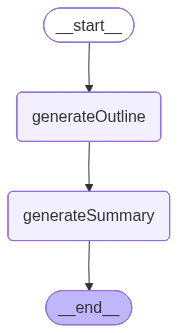

In [16]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())